# 05. Travel Demand Forecasting Model
This notebook implements the complete machine learning pipeline: from data loading to training advanced regressors (Random Forest & XGBoost).

**Objective**: Predict hourly taxi demand for specific zones.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Load Engineered Features
print(">>> Loading Engineered Features...")
df = pd.read_parquet('../dataset/processed/engineered_features.parquet')

# Fix: Create Datetime column for splitting and plotting
df['Datetime'] = pd.to_datetime(df['pickup_time_key'].astype(str), format='%Y%m%d%H')

print(f"Total records loaded: {len(df)}")
df.head()

>>> Loading Engineered Features...
Total records loaded: 2512267


,pickup_time_key,pulocationid,total_demand,hour,day_of_week_number,is_weekend,lag_demand_1h,lag_demand_2h,lag_demand_24h,lag_demand_168h,rolling_mean_6h,hour_sin,hour_cos,day_sin,day_cos,Datetime
0,2025060918,81,180,18,1,False,1,2,192,1,97.666667,-1.0,-0.000004,0.781831,0.62349,2025-06-09 18:00:00
1,2025060918,223,260,18,1,False,2,6,7,9,132.000000,-1.0,-0.000004,0.781831,0.62349,2025-06-09 18:00:00
2,2025060918,157,136,18,1,False,1,114,4,32,65.500000,-1.0,-0.000004,0.781831,0.62349,2025-06-09 18:00:00
3,2025060918,186,250,18,1,False,394,2,259,1,204.666667,-1.0,-0.000004,0.781831,0.62349,2025-06-09 18:00:00
4,2025060918,260,264,18,1,False,2,2,250,3,93.333333,-1.0,-0.000004,0.781831,0.62349,2025-06-09 18:00:00


### Cell 3: Time-Based Train/Test Split
We use November 2025 as the hold-out test set to simulate future prediction.

In [7]:

train_df = df[df['Datetime'] < '2025-11-01']
test_df = df[df['Datetime'] >= '2025-11-01']

features_cols = [
    'pulocationid', 'hour', 'day_of_week_number', 'is_weekend', 'hour_sin', 'hour_cos',
    'lag_demand_1h', 'lag_demand_2h', 'lag_demand_24h', 'lag_demand_168h'
]
target_col = 'total_demand'

X_train, y_train = train_df[features_cols], train_df[target_col]
X_test, y_test = test_df[features_cols], test_df[target_col]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 2106933 | Test size: 405334


### Cell 5: Train Baseline Model (Random Forest)

In [8]:
print(">>> Training Random Forest Baseline...")
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

def print_metrics(model_name, y_true, y_pred):
    print(f"--- {model_name} Results ---")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.2f}")

print_metrics("Random Forest", y_test, rf_preds)

import joblib
import os
os.makedirs('../saved_models/random_forest', exist_ok=True)
joblib.dump(rf_model, '../saved_models/random_forest/rf_baseline_model.joblib')
print("Random Forest model saved to ../saved_models/random_forest/rf_baseline_model.joblib")

>>> Training Random Forest Baseline...
--- Random Forest Results ---
RMSE: 90.91
MAE:  57.09
R2 Score: 0.69
Random Forest model saved to ../saved_models/random_forest/rf_baseline_model.joblib


### Cell 7: Train Advanced Model (XGBoost)

In [9]:
print(">>> Training Tuned XGBoost...")
xgb_model = XGBRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=7, 
    subsample=0.8, 
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print_metrics("XGBoost Tuned", y_test, xgb_preds)

>>> Training Tuned XGBoost...
--- XGBoost Tuned Results ---
RMSE: 78.70
MAE:  47.90
R2 Score: 0.77


### Cell 8: Actual vs Predicted Visualization (Zone 161 - Midtown)

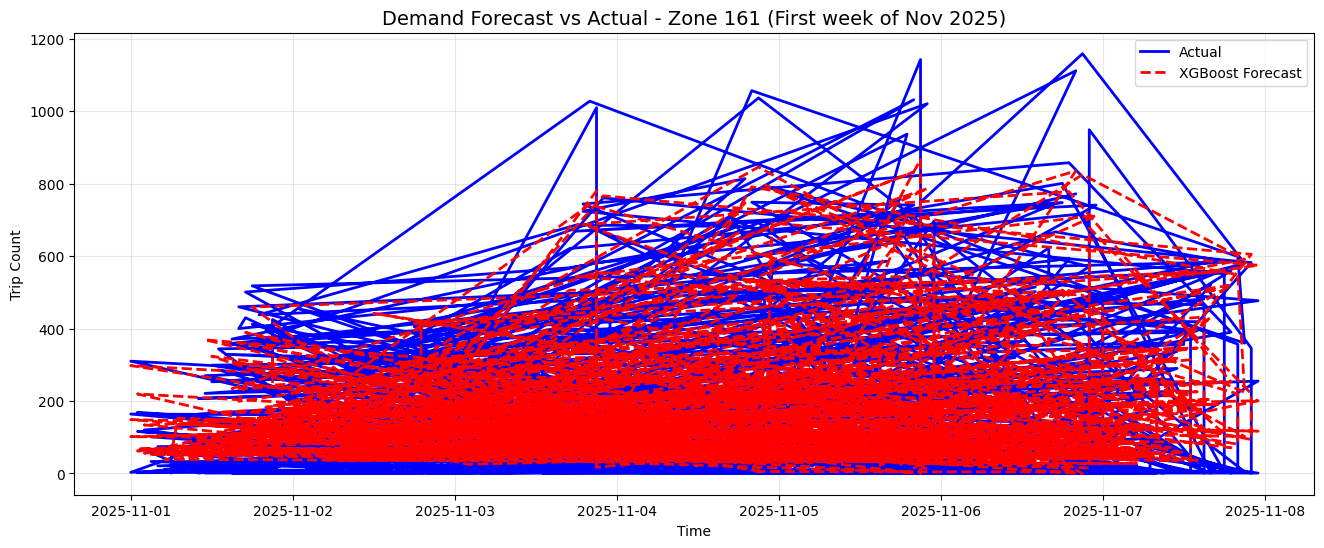

In [10]:
zone_id = 161 # Midtown Manhattan
zone_test = test_df[(test_df['pulocationid'] == zone_id) & (test_df['Datetime'] < '2025-11-08')]

xgb_preds_zone = xgb_model.predict(zone_test[features_cols])

plt.figure(figsize=(16, 6))
plt.plot(zone_test['Datetime'], zone_test['total_demand'], label='Actual', color='blue', linewidth=2)
plt.plot(zone_test['Datetime'], xgb_preds_zone, label='XGBoost Forecast', color='red', linestyle='dashed', linewidth=2)

plt.title(f'Demand Forecast vs Actual - Zone {zone_id} (First week of Nov 2025)', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Trip Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()